# Pipeline V3 – DIS22 ArXiv Warriors

**Zweistufige Kaskade: Regex → spaCy NER+Dep**

| Methode | Stufe | Beschreibung |
|---|---|---|
| Regex | 1 | Zahlenwerte-Matching, schnell & deterministisch |
| spaCy NER + Dep | 2 | NER filtert Zahlentypen, Dep prüft Caption-Satz-Kontext |

**Hinweis:** LLM (Ollama/Llama 3.2) wurde in allen Tests deaktiviert: alle 1 579 LLM-Calls haben mit Exception/Timeout gefehlt. Die Kaskade läuft daher als reine Regex → spaCy Pipeline.  
**Overlap-Scores** beider Methoden + **Random-Forest-Klassifikation** (80/20 Train/Test-Split) landen in der Ergebnis-CSV.

## 0. Setup & Abhängigkeiten

In [1]:
import sys
!{sys.executable} -m pip install scikit-learn pandas tqdm matplotlib seaborn requests -q

# spaCy
try:
    import spacy
    try:
        spacy.load('en_core_web_sm')
        print('✓ spaCy + en_core_web_sm bereits vorhanden')
    except OSError:
        !{sys.executable} -m spacy download en_core_web_sm -q
        print('✓ en_core_web_sm heruntergeladen')
except ImportError:
    !{sys.executable} -m pip install spacy -q
    !{sys.executable} -m spacy download en_core_web_sm -q
    print('✓ spaCy installiert')

print('✓ Alle Pakete bereit')

✓ spaCy + en_core_web_sm bereits vorhanden
✓ Alle Pakete bereit


## 1. Imports & Pfade

In [2]:
import json, re, pathlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# Konfiguration
RANDOM_SEED  = 42
WINDOW_SIZE  = 1000
USE_LLM      = False
OLLAMA_HOST  = 'http://localhost:11434'
OLLAMA_MODEL = 'llama3.2'

# Pfade (KITeGG-Server)
PROJECT_DIR  = pathlib.Path('/home/jovyan')
DATA_DIR     = PROJECT_DIR / 'team4_parsedTables' / 'json'
RESULTS_PATH = PROJECT_DIR / 'results_v3.csv'
VIZ_DIR      = PROJECT_DIR / 'viz_v3'
VIZ_DIR.mkdir(exist_ok=True)

json_files = sorted(DATA_DIR.glob('*.json'))

def has_parsed_tables(fpath):
    try:
        with open(fpath, encoding='utf-8') as f:
            doc = json.load(f)
        tables = doc.get('tables', [])
        return any(
            t.get('content') and t.get('content') not in ('{}', '', None)
            for t in tables
        )
    except Exception:
        return False

print('Filtere JSON-Dateien...')
json_files = [f for f in tqdm(json_files, desc='Filter') if has_parsed_tables(f)]
print(f'{len(json_files)} Dateien mit geparseten Tabellen (von ursprunglich {len(sorted(DATA_DIR.glob("*.json")))})')

print(f'Projekt-Verzeichnis    : {PROJECT_DIR}')
print(f'team4_parsedTables     : {DATA_DIR}  (existiert: {DATA_DIR.exists()})')
print(f'JSON-Dateien gefunden  : {len(json_files)}')
print(f'LLM                    : DEAKTIVIERT')


Filtere JSON-Dateien...


Filter:   0%|          | 0/7677 [00:00<?, ?it/s]

3810 Dateien mit geparseten Tabellen (von ursprunglich 7677)
Projekt-Verzeichnis    : /home/jovyan
team4_parsedTables     : /home/jovyan/team4_parsedTables/json  (existiert: True)
JSON-Dateien gefunden  : 3810
LLM                    : DEAKTIVIERT


## 2. Hilfsfunktionen

In [3]:
# ══════════════════════════════════════════════════════════
# Zahlenextraktion & Normalisierung
# ══════════════════════════════════════════════════════════

def clean_text(text):
    """Entfernt bekannte False-Positive-Quellen (Jahre, Abbildungs-Nummern etc.)"""
    if not text:
        return ''
    text = re.sub(r'\[\d[\d,;\s\-]*\]', ' ', text)           # [1], [1,2]
    text = re.sub(r'\b(19|20)\d{2}\b', ' ', text)             # Jahreszahlen
    text = re.sub(r'\bFig\.?\s*\d+\b', ' ', text)            # Fig. 3
    text = re.sub(r'\bTable\s*[A-Za-z]?\s*\d+\b', ' ', text) # Table 2
    text = re.sub(r'\bEq\.?\s*\d+\b', ' ', text)             # Eq. 5
    text = re.sub(r'\bp\s*[<>=]\s*0\.\d+', ' PVAL ', text)   # p<0.05
    return text


def normalize_number(s):
    """Normalisiert einen Zahlen-String (Komma→Punkt, Tausender-Trenner etc.)"""
    s = str(s).strip()
    s = re.sub(r'[%±≈~<>≤≥°]', '', s)
    if re.match(r'^\d{1,3}(,\d{3})+$', s):   # 1,234 → Tausender-Trenner
        s = s.replace(',', '')
    else:
        s = s.replace(',', '.')               # Dezimalkomma → Punkt
    try:
        return str(round(float(s), 6))
    except ValueError:
        return ''


def extract_numbers_regex(text):
    """Extraktion von Zahlenwerten via Regex. Gibt Set von normalisierten Zahlen zurück."""
    text = clean_text(str(text))
    exact = set()
    # Wissenschaftliche Notation: 2.5e-3
    for m in re.finditer(r'\d+\.?\d*[eE][+-]?\d+', text):
        n = normalize_number(m.group())
        if n: exact.add(n)
    # Zahl + Einheit: 75% / 42 mg
    for m in re.finditer(r'(?:n\s*=\s*)?(\d+)\s*([%µg]|mg|ml|kg|mm|cm|kb|mb|bp)\b', text):
        n = normalize_number(m.group(1))
        if n: exact.add(n + m.group(2).lower())
    # Dezimalzahl: 3.14 / 0,87
    for m in re.finditer(r'\b\d+[.,]\d+\b', text):
        n = normalize_number(m.group())
        if n: exact.add(n)
    # Bereich: 14–36%
    for m in re.finditer(r'(\d+[.,]?\d*)\s*[-–]\s*(\d+[.,]?\d*)\s*(%|\w{1,4})', text):
        u = m.group(3).lower()
        for g in (m.group(1), m.group(2)):
            n = normalize_number(g)
            if n: exact.add(n + u)
    # Filter: triviale Ganzzahlen, sehr große Zahlen
    result = set()
    for n in exact:
        if not n: continue
        try:
            base = re.match(r'[\d.]+', n)
            if not base: continue
            v = float(base.group())
            if v in (0.0, 1.0, 2.0) and '.' not in n.split('%')[0]: continue
            if v > 100_000: continue
        except Exception:
            pass
        result.add(n)
    return result


def fuzzy_match(table_nums, text_nums, tolerance=0.05):
    """Anzahl gematchter Tabellenzahlen mit ±5% Toleranz."""
    matched = 0
    for tn in table_nums:
        try:
            base = re.match(r'[\d.]+', tn)
            if not base: continue
            tv = float(base.group())
        except Exception:
            continue
        for xn in text_nums:
            try:
                base2 = re.match(r'[\d.]+', xn)
                if not base2: continue
                xv = float(base2.group())
                if tv == 0:
                    if xv == 0: matched += 1; break
                elif abs(tv - xv) / abs(tv) <= tolerance:
                    matched += 1; break
            except Exception:
                continue
    return matched


# ══════════════════════════════════════════════════════════
# Textfenster & Tabelleninhalte
# ══════════════════════════════════════════════════════════

def get_window_bidirectional(full_text, reference, before=WINDOW_SIZE, after=WINDOW_SIZE):
    """Bidirektionales Textfenster: ±WINDOW_SIZE Zeichen um Referenzstelle."""
    if not reference or not full_text:
        return reference or ''
    ref_pos = full_text.find(reference)
    if ref_pos >= 0:
        return full_text[max(0, ref_pos - before): ref_pos + len(reference) + after]
    short = reference[:60].strip()
    pos = full_text.find(short)
    if pos >= 0:
        return full_text[max(0, pos - before): pos + len(short) + after]
    return reference


def extract_table_cells(table):
    """Gibt alle Zellwerte einer Tabelle als einzelnen String zurück."""
    try:
        raw = table.get('content', '{}')
        content = json.loads(raw) if isinstance(raw, str) else (raw or {})
        return ' '.join(
            str(v) for row in content.get('data', []) for v in row
            if v is not None and str(v).strip()
        )
    except Exception:
        return ''


def extract_table_features(table):
    """Berechnet Größen- und Typ-Features einer Tabelle."""
    try:
        raw = table.get('content', '{}')
        content = json.loads(raw) if isinstance(raw, str) else (raw or {})
    except Exception:
        content = {}
    columns  = content.get('columns', [])
    data     = content.get('data', [])
    n_rows   = len(data)
    n_cols   = len(columns) if columns else (len(data[0]) if data else 0)
    n_cells  = n_rows * n_cols
    flat     = [str(c) for row in data for c in row if c is not None and str(c).strip()]

    num_count = 0
    for c in flat:
        s = c.strip().replace(',','').replace('(','').replace(')','').replace('%','')
        try:
            float(s.split('±')[0].split('/')[0].split('–')[0])
            num_count += 1
        except Exception:
            pass
    numeric_ratio = num_count / len(flat) if flat else 0.0

    size_cat     = 'small'   if n_cells <= 12 else 'medium' if n_cells <= 50 else 'large'
    content_type = 'numeric' if numeric_ratio >= 0.70 else 'text' if numeric_ratio <= 0.20 else 'mixed'

    return {
        'n_rows': n_rows, 'n_cols': n_cols, 'n_cells': n_cells,
        'size_cat': size_cat, 'numeric_ratio': round(numeric_ratio, 4),
        'content_type': content_type, 'data': data,
    }


def keyword_overlap(table_cells_list, ref_text):
    """Keyword-Matching für text-lastige Tabellen (content_type == 'text')."""
    ref_lower  = ref_text.lower()
    long_words = [w.lower() for cell in table_cells_list
                  for w in str(cell).split() if len(w) > 5]
    if not long_words:
        return 0.0
    matched = sum(1 for w in long_words if w in ref_lower)
    return round(matched / len(long_words), 4)


# ══════════════════════════════════════════════════════════
# Referenz-Features
# ══════════════════════════════════════════════════════════

_QUAL = re.compile(
    r'demonstrat|reveal|indicat|suggest|confirm|illustrat|display'
    r'|report|highlight|summar|showed|shows\b|found\b|observed'
    r'|measured|obtained|compared|higher|lower|significant'
    r'|increased|decreased|elevated|reduced|greater|smaller', re.I)
_PTR = re.compile(
    r'see table|as shown in|shown in table|listed in|provided in'
    r'|as in table|refer to table|presented in table|are shown in|is shown in', re.I)

def extract_ref_features(refs):
    """Qualitative & Pointer-Phrasen zählen, Wortanzahl & Zahlen in Refs."""
    if not refs:
        return 0, 0, 0, 0
    ref_text = ' '.join(refs)
    return (
        len(_QUAL.findall(ref_text)),
        len(_PTR.findall(ref_text)),
        len(ref_text.split()),
        len(re.findall(r'\d+[.,]\d+|\d+\s*%', ref_text)),
    )


print('✓ Hilfsfunktionen geladen')

✓ Hilfsfunktionen geladen


## 3. Methode A – Regex Overlap (Stufe 1)

In [4]:
def compute_regex_overlap(table, full_text, features):
    """
    Methode A: Regex-basierter numerischer Overlap.
    Für text-lastige Tabellen: Keyword-Matching statt Zahlenabgleich.
    Returns: overlap_score (float 0–1)
    """
    refs = [r for r in (table.get('references') or [])
            if isinstance(r, str) and len(r.strip()) > 10]
    if not refs:
        return 0.0

    table_text   = extract_table_cells(table)
    content_type = features['content_type']

    windows = [get_window_bidirectional(full_text, ref) for ref in refs]
    window_combined = ' '.join(w for w in windows if w)

    if content_type == 'text':
        table_cells = [str(c) for row in features['data'] for c in row]
        return keyword_overlap(table_cells, window_combined)

    table_nums  = extract_numbers_regex(table_text)
    window_nums = extract_numbers_regex(window_combined)
    if not table_nums:
        return 0.0
    matched = fuzzy_match(table_nums, window_nums)
    return round(min(matched / len(table_nums), 1.0), 4)


print('✓ Methode A (Regex) geladen')

✓ Methode A (Regex) geladen


## 4. Methode B – spaCy NER + Dependency (Stufe 2)

In [5]:
try:
    import spacy
    nlp = spacy.load('en_core_web_sm')
    SPACY_AVAILABLE = True
    print('✓ spaCy Modell geladen: en_core_web_sm')
except Exception as e:
    nlp = None
    SPACY_AVAILABLE = False
    print(f'⚠ spaCy nicht verfügbar: {e}')
    print('  → Pipeline läuft mit Regex + optionalem LLM')


def compute_spacy_overlap(table, full_text, features):
    """
    Methode B: spaCy NER + Dependency-Overlap.

    NER-Score  : CARDINAL/PERCENT/QUANTITY Entities, Jahreszahlen gefiltert,
                 Fuzzy-Match gegen Tabellenzahlen.
    Dep-Score  : Nur Zahlen in Sätzen die ein Caption-Keyword enthalten.
    Combined   : Mittelwert(NER, Dep)

    Returns: (ner_score, dep_score, combined_score)
    """
    if not SPACY_AVAILABLE or nlp is None:
        return 0.0, 0.0, 0.0

    refs = [r for r in (table.get('references') or [])
            if isinstance(r, str) and len(r.strip()) > 10]
    if not refs:
        return 0.0, 0.0, 0.0

    table_text = extract_table_cells(table)
    table_nums = extract_numbers_regex(table_text)
    if not table_nums:
        return 0.0, 0.0, 0.0

    caption = str(table.get('caption') or table.get('name') or '')
    caption_kws = {w.lower() for w in re.split(r'\W+', caption) if len(w) > 3}

    windows = [get_window_bidirectional(full_text, ref) for ref in refs]
    combined_text = (' '.join(w for w in windows if w) or ' '.join(refs))[:30000]

    doc = nlp(combined_text)

    # ── NER-Score ────────────────────────────────────────────────────────
    ner_numbers = set()
    for ent in doc.ents:
        if ent.label_ not in ('CARDINAL', 'PERCENT', 'QUANTITY'):
            continue
        raw = ent.text.strip()
        try:
            val_str = re.sub(r'[^\d.]', '', raw)
            val = float(val_str) if val_str else None
            if val and 1900 <= val <= 2030 and '.' not in raw:
                continue  # Jahreszahl rausfiltern
        except Exception:
            pass
        n = normalize_number(re.sub(r'[^\d.,eE+\-]', '', raw))
        if n:
            ner_numbers.add(n)

    ner_matched = fuzzy_match(table_nums, ner_numbers)
    ner_score   = round(min(ner_matched / len(table_nums), 1.0), 4)

    # ── Dep-Score (Caption-Keyword-Sätze) ────────────────────────────────
    dep_numbers = set()
    for sent in doc.sents:
        sent_lower = sent.text.lower()
        if caption_kws and any(kw in sent_lower for kw in caption_kws):
            for m in re.finditer(r'\b\d+[.,]?\d*\b', sent.text):
                n = normalize_number(m.group())
                if n:
                    dep_numbers.add(n)

    dep_matched = fuzzy_match(table_nums, dep_numbers)
    dep_score   = round(min(dep_matched / len(table_nums), 1.0), 4)

    combined = round((ner_score + dep_score) / 2, 4)
    return ner_score, dep_score, combined


print('✓ Methode B (spaCy NER + Dep) geladen')

✓ spaCy Modell geladen: en_core_web_sm
✓ Methode B (spaCy NER + Dep) geladen


## 5. Methode C – LLM via Ollama (DEAKTIVIERT)

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Methode C – LLM via Ollama  (DAUERHAFT DEAKTIVIERT)
#
# Befund: In einem vollständigen Testlauf über 3 810 Dokumente wurden
# 1 579 Tabellen als "ambig" eingestuft und hätten per LLM entschieden
# werden sollen. Ollama war erreichbar (HTTP 200), aber jeder einzelne
# Call hat mit Exception/Timeout geendet → method_used = 'spacy:llm_fallback'
# für alle 1 579 Fälle, kein einziger 'llm'-Treffer.
#
# Konsequenz:
#   • USE_LLM = False  (dauerhaft in der Konfiguration)
#   • LLM_AVAILABLE = False
#   • Die Kaskade läuft als Regex → spaCy (zweistufig)
#   • Ein separater numerischer LLM-Overlap-Score existiert nicht,
#     da das Modell nur Labels, keine Floats zurückgibt.
# ─────────────────────────────────────────────────────────────────────────────

LLM_AVAILABLE = False
print('ℹ  Methode C (LLM) dauerhaft deaktiviert.')
print('   Kaskade: Stufe 1 Regex → Stufe 2 spaCy only.')


ℹ  Methode C (LLM) dauerhaft deaktiviert.
   Kaskade: Stufe 1 Regex → Stufe 2 spaCy only.


## 6. Kaskaden-Klassifikator (Regex → spaCy)

In [7]:
# Größenabhängige Schwellenwerte
_THRESHOLDS = {
    'small':  {'info': 0.60, 'partial_low': 0.10},
    'medium': {'info': 0.40, 'partial_low': 0.08},
    'large':  {'info': 0.20, 'partial_low': 0.05},
}


def _decide_label(overlap, ref_wc, t):
    """Entscheidungsbaum basierend auf Overlap-Score und Schwellenwerten."""
    if ref_wc < 10 and overlap < t['partial_low']:
        return 'only_table', 'high'
    if overlap >= t['info'] and ref_wc >= 15:
        return 'info_in_text', 'high'
    if overlap >= t['info'] * 0.6 and ref_wc >= 40:
        return 'info_in_text', 'low'
    if t['partial_low'] <= overlap < t['info']:
        return 'partial', 'low'
    if overlap < t['partial_low'] and ref_wc >= 15:
        return 'only_table', 'low'
    return 'partial', 'low'


def classify_cascade(table, full_text, features):
    """
    Kaskaden-Klassifikator: Regex → spaCy (zweistufig)

    Stufe 1 (Regex)  : high confidence → Label direkt
                       low confidence  → weiter zu spaCy
    Stufe 2 (spaCy)  : Finales Label

    spaCy-Scores werden immer berechnet (für Visualisierung & RF-Features).

    Returns: dict mit allen Scores + cascade_label + method_used
    """
    refs = [r for r in (table.get('references') or [])
            if isinstance(r, str) and len(r.strip()) > 10]

    result = dict(
        overlap_regex          = 0.0,
        overlap_spacy_ner      = 0.0,
        overlap_spacy_dep      = 0.0,
        overlap_spacy_combined = 0.0,
        cascade_label          = 'no_refs',
        method_used            = 'rule:no_refs',
    )

    if not refs:
        return result

    t      = _THRESHOLDS[features['size_cat']]
    ref_wc = len(' '.join(refs).split())

    # ── Stufe 1: Regex ───────────────────────────────────────────────────
    ov_r = compute_regex_overlap(table, full_text, features)
    result['overlap_regex'] = ov_r
    label_r, conf_r = _decide_label(ov_r, ref_wc, t)

    # spaCy immer berechnen (für Visualisierung und RF-Features)
    ner, dep, comb = compute_spacy_overlap(table, full_text, features)
    result['overlap_spacy_ner']      = ner
    result['overlap_spacy_dep']      = dep
    result['overlap_spacy_combined'] = comb

    if conf_r == 'high':
        result['cascade_label'] = label_r
        result['method_used']   = 'regex:high'
        return result

    # ── Stufe 2: spaCy ───────────────────────────────────────────────────
    if SPACY_AVAILABLE:
        label_s, _ = _decide_label(comb, ref_wc, t)
    else:
        label_s = label_r

    result['cascade_label'] = label_s
    result['method_used']   = 'spacy' if SPACY_AVAILABLE else 'regex:low'
    return result


print('✓ Kaskaden-Klassifikator geladen (Regex → spaCy, LLM deaktiviert)')


✓ Kaskaden-Klassifikator geladen (Regex → spaCy, LLM deaktiviert)


## 7. Alle JSON-Dateien verarbeiten (team4_parsedTables)

In [8]:
import random

random.seed(RANDOM_SEED)
shuffled = list(sorted(json_files))
random.shuffle(shuffled)

split_idx   = int(len(shuffled) * 0.80)
train_files = shuffled[:split_idx]
test_files  = shuffled[split_idx:]
print(f'Datei-Split  : {len(train_files)} Train  |  {len(test_files)} Test')


def process_files(files, split_label):
    rows = []
    MIN_REF_LEN = 10
    for fpath in tqdm(files, desc=split_label):
        try:
            with open(fpath, encoding='utf-8') as f:
                doc = json.load(f)
        except Exception:
            continue
        full_text = doc.get('text', '')
        doi       = (doc.get('doi') or fpath.stem).strip()
        meta      = doc.get('metadata') or {}
        year      = str(meta.get('preprint_date', ''))[:4]
        category  = meta.get('preprint_category', '')
        for t_idx, table in enumerate(doc.get('tables', [])):
            table_name = (table.get('name') or '').strip()
            caption    = str(table.get('caption') or '')
            refs       = [r for r in (table.get('references') or [])
                          if isinstance(r, str) and len(r.strip()) > MIN_REF_LEN]
            features = extract_table_features(table)
            qual, ptr, ref_wc, ref_nums = extract_ref_features(refs)
            cascade  = classify_cascade(table, full_text, features)
            rows.append({
                'split'          : split_label,
                'doi'            : doi,
                'table_name'     : table_name,
                'caption'        : caption[:120],
                'caption_key'    : caption.strip()[:60],
                'year'           : year,
                'category'       : category,
                't_idx'          : t_idx,
                'n_rows'         : features['n_rows'],
                'n_cols'         : features['n_cols'],
                'n_cells'        : features['n_cells'],
                'size_cat'       : features['size_cat'],
                'numeric_ratio'  : features['numeric_ratio'],
                'content_type'   : features['content_type'],
                'n_refs'         : len(refs),
                'ref_wc'         : ref_wc,
                'qual_count'     : qual,
                'ptr_count'      : ptr,
                'ref_nums'       : ref_nums,
                'overlap_regex'          : cascade['overlap_regex'],
                'overlap_spacy_ner'      : cascade['overlap_spacy_ner'],
                'overlap_spacy_dep'      : cascade['overlap_spacy_dep'],
                'overlap_spacy_combined' : cascade['overlap_spacy_combined'],
                'cascade_label'  : cascade['cascade_label'],
                'method_used'    : cascade['method_used'],
            })
    return rows


rows_train = process_files(train_files, 'train')
rows_test  = process_files(test_files,  'test')

df = pd.DataFrame(rows_train + rows_test)
df['has_overlap']    = (df['overlap_regex'] > 0).astype(int)
df['overlap_x_refs'] = (df['overlap_regex'] * df['n_refs']).round(4)
df['ref_density']    = (df['n_refs'] / (df['ref_wc'] + 1)).round(4)

df_train = df[df['split'] == 'train'].copy()
df_test  = df[df['split'] == 'test'].copy()

print(f'Tabellen gesamt : {len(df)}  (Train: {len(df_train)} | Test: {len(df_test)})')
for split_name, sub in [('Train', df_train), ('Test', df_test)]:
    print(f'\n{split_name}:')
    print(f'  ohne Referenzen : {(sub["n_refs"] == 0).sum()}')
    print(f'  mit Referenzen  : {(sub["n_refs"] > 0).sum()}')
    sub_r = sub[sub['n_refs'] > 0]
    for col, name in [('overlap_regex','Regex'), ('overlap_spacy_combined','spaCy Combined')]:
        print(f'  O {name:<20} : {sub_r[col].mean():.4f}')

Datei-Split  : 3048 Train  |  762 Test


train:   0%|          | 0/3048 [00:00<?, ?it/s]

test:   0%|          | 0/762 [00:00<?, ?it/s]

Tabellen gesamt : 10131  (Train: 8084 | Test: 2047)

Train:
  ohne Referenzen : 1258
  mit Referenzen  : 6826
  O Regex                : 0.1602
  O spaCy Combined       : 0.1446

Test:
  ohne Referenzen : 342
  mit Referenzen  : 1705
  O Regex                : 0.1759
  O spaCy Combined       : 0.1503


## 8. Analyse: Train vs. Test nach Tabellentyp & -groesse

> Kein Random Forest. Die Kaskade (Regex -> spaCy) ist das finale Modell. Geprueft wird ob Ergebnisse zwischen Train/Test konsistent sind und wie Tabellengroesse/Inhaltstyp die Overlap-Scores beeinflusst.

In [12]:
LABEL_ORDER = ['info_in_text', 'partial', 'only_table', 'no_refs']

print('=' * 60)
print('Label-Verteilung  Train vs. Test')
print('=' * 60)
comp = pd.DataFrame({
    'Train'  : df_train['cascade_label'].value_counts().reindex(LABEL_ORDER, fill_value=0),
    'Test'   : df_test['cascade_label'].value_counts().reindex(LABEL_ORDER, fill_value=0),
})
comp['Train %'] = (comp['Train'] / len(df_train) * 100).round(1)
comp['Test %']  = (comp['Test']  / len(df_test)  * 100).round(1)
print(comp.to_string())

print('\n' + '=' * 60)
print('Overlap-Scores nach Tabellengroesse  (Test-Set, nur mit Refs)')
print('=' * 60)
df_test_r = df_test[df_test['n_refs'] > 0]
for size in ['small', 'medium', 'large']:
    sub = df_test_r[df_test_r['size_cat'] == size]
    if len(sub) == 0:
        continue
    print(f'\n{size.upper()}  ({len(sub)} Tabellen)')
    for col, name in [('overlap_regex','Regex'), ('overlap_spacy_ner','spaCy NER'),
                      ('overlap_spacy_dep','spaCy Dep'), ('overlap_spacy_combined','spaCy Combined')]:
        print(f'  {name:<22} : O {sub[col].mean():.4f}  |  Kein Overlap: {(sub[col]==0).mean():.1%}')
    print('  Label-Mix:', sub['cascade_label'].value_counts().to_dict())

print('\n' + '=' * 60)
print('Overlap-Scores nach Inhaltstyp  (Test-Set, nur mit Refs)')
print('=' * 60)
for ctype in ['numeric', 'mixed', 'text']:
    sub = df_test_r[df_test_r['content_type'] == ctype]
    if len(sub) == 0:
        continue
    print(f'\n{ctype.upper()}  ({len(sub)} Tabellen)')
    for col, name in [('overlap_regex','Regex'), ('overlap_spacy_combined','spaCy Combined')]:
        print(f'  {name:<22} : O {sub[col].mean():.4f}  |  Kein Overlap: {(sub[col]==0).mean():.1%}')
    print('  Label-Mix:', sub['cascade_label'].value_counts().to_dict())

print('\n' + '=' * 60)
print('Konsistenz: Anteilsdifferenz Train vs. Test je Label')
print('=' * 60)
for lbl in LABEL_ORDER:
    t_pct  = (df_train['cascade_label'] == lbl).mean()
    te_pct = (df_test['cascade_label']  == lbl).mean()
    diff   = abs(t_pct - te_pct)
    flag   = '  OK' if diff < 0.02 else '  !! Abweichung'
    print(f'  {lbl:<15} Train {t_pct:.1%}  Test {te_pct:.1%}  Diff {diff:.1%}{flag}')

Label-Verteilung  Train vs. Test
               Train  Test  Train %  Test %
cascade_label                              
info_in_text    2501   666     30.9    32.5
partial         1263   281     15.6    13.7
only_table      3062   758     37.9    37.0
no_refs         1258   342     15.6    16.7

Overlap-Scores nach Tabellengroesse  (Test-Set, nur mit Refs)

SMALL  (372 Tabellen)
  Regex                  : O 0.1151  |  Kein Overlap: 72.6%
  spaCy NER              : O 0.0903  |  Kein Overlap: 75.5%
  spaCy Dep              : O 0.0851  |  Kein Overlap: 75.0%
  spaCy Combined         : O 0.0877  |  Kein Overlap: 72.3%
  Label-Mix: {'only_table': 270, 'info_in_text': 58, 'partial': 44}

MEDIUM  (772 Tabellen)
  Regex                  : O 0.2090  |  Kein Overlap: 38.9%
  spaCy NER              : O 0.1722  |  Kein Overlap: 44.6%
  spaCy Dep              : O 0.1756  |  Kein Overlap: 46.9%
  spaCy Combined         : O 0.1739  |  Kein Overlap: 39.6%
  Label-Mix: {'only_table': 317, 'info_in_tex

## 9. Finale Labels (Kaskade direkt)

In [13]:
df['final_label'] = df['cascade_label']

print('Finale Label-Verteilung (gesamt):')
print(df['final_label'].value_counts().reindex(LABEL_ORDER, fill_value=0).to_string())

print('\nFinale Label-Verteilung nach Tabellengroesse:')
print(pd.crosstab(df['size_cat'], df['final_label'],
                  rownames=['Groesse'], colnames=['Label']).to_string())

print('\nFinale Label-Verteilung nach Inhaltstyp:')
print(pd.crosstab(df['content_type'], df['final_label'],
                  rownames=['Inhaltstyp'], colnames=['Label']).to_string())

Finale Label-Verteilung (gesamt):
final_label
info_in_text    3167
partial         1544
only_table      3820
no_refs         1600

Finale Label-Verteilung nach Tabellengroesse:
Label    info_in_text  no_refs  only_table  partial
Groesse                                            
large            1538      506         847      429
medium           1367      667        1656      873
small             262      427        1317      242

Finale Label-Verteilung nach Inhaltstyp:
Label       info_in_text  no_refs  only_table  partial
Inhaltstyp                                            
mixed               1022      377        1123      593
numeric             1025      413         954      678
text                1120      810        1743      273


## 10. Visualisierungen – Overlap-Scores & Ergebnisse

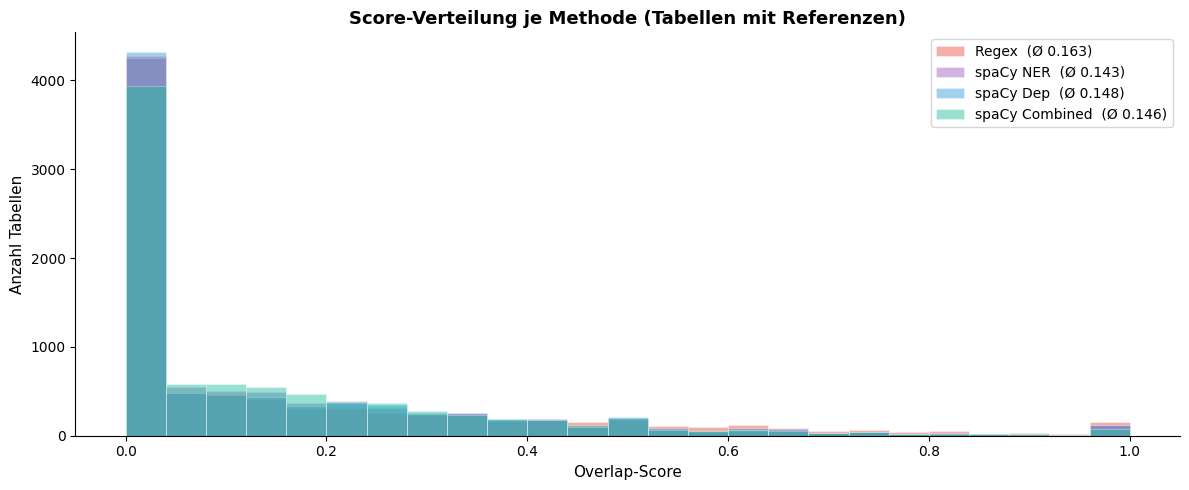

✓ /home/jovyan/viz_v3/v3_01_score_verteilung.png


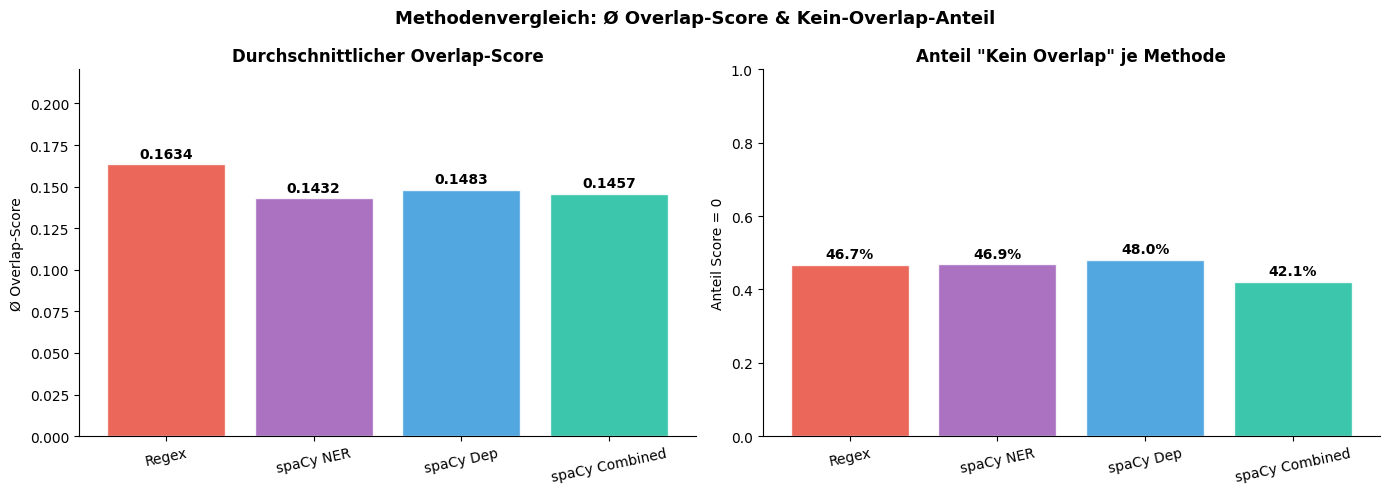

✓ /home/jovyan/viz_v3/v3_02_methodenvergleich.png


KeyError: 'rf_label'

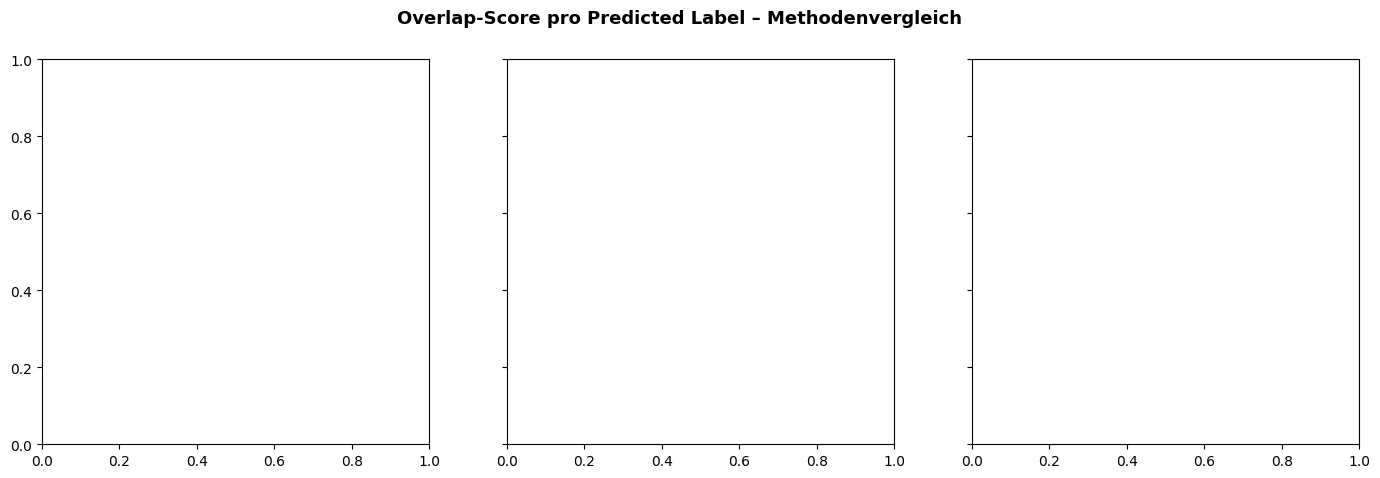

In [14]:
LABEL_ORDER  = ['info_in_text', 'partial', 'only_table', 'no_refs']
LABEL_COLORS = {'info_in_text': '#2ecc71', 'partial': '#3498db',
                'only_table': '#e67e22', 'no_refs': '#95a5a6'}

df_r = df[df['n_refs'] > 0].copy()  # Nur Tabellen mit Referenzen für Score-Plots


# ══════════════════════════════════════════════════════════════════════════
# PLOT 1: Score-Verteilung je Methode (Histogramme überlagert)
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))
hist_methods = [
    ('Regex',          'overlap_regex',         '#e74c3c'),
    ('spaCy NER',      'overlap_spacy_ner',      '#9b59b6'),
    ('spaCy Dep',      'overlap_spacy_dep',      '#3498db'),
    ('spaCy Combined', 'overlap_spacy_combined', '#1abc9c'),
]
bins = np.linspace(0, 1, 26)
for name, col, color in hist_methods:
    vals = df_r[col].clip(0, 1).dropna()
    ax.hist(vals, bins=bins, alpha=0.45, color=color,
            label=f'{name}  (Ø {vals.mean():.3f})',
            edgecolor='white', linewidth=0.5)
ax.set_xlabel('Overlap-Score', fontsize=11)
ax.set_ylabel('Anzahl Tabellen', fontsize=11)
ax.set_title('Score-Verteilung je Methode (Tabellen mit Referenzen)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
p = VIZ_DIR / 'v3_01_score_verteilung.png'
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ {p}')


# ══════════════════════════════════════════════════════════════════════════
# PLOT 2: Ø Score & Kein-Overlap-Anteil je Methode (Balken)
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Methodenvergleich: Ø Overlap-Score & Kein-Overlap-Anteil',
             fontsize=13, fontweight='bold')

method_names = ['Regex', 'spaCy NER', 'spaCy Dep', 'spaCy Combined']
method_cols  = ['overlap_regex', 'overlap_spacy_ner', 'overlap_spacy_dep', 'overlap_spacy_combined']
method_clrs  = ['#e74c3c', '#9b59b6', '#3498db', '#1abc9c']

means = [df_r[c].mean() for c in method_cols]
no_ov = [(df_r[c] == 0).mean() for c in method_cols]

ax = axes[0]
bars = ax.bar(method_names, means, color=method_clrs, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Ø Overlap-Score')
ax.set_title('Durchschnittlicher Overlap-Score', fontweight='bold')
ax.set_ylim(0, max(means) * 1.35 if max(means) > 0 else 0.5)
ax.tick_params(axis='x', rotation=12)
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
bars2 = ax.bar(method_names, no_ov, color=method_clrs, edgecolor='white', alpha=0.85)
for bar, val in zip(bars2, no_ov):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Anteil Score = 0')
ax.set_title('Anteil "Kein Overlap" je Methode', fontweight='bold')
ax.set_ylim(0, 1.0)
ax.tick_params(axis='x', rotation=12)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
p = VIZ_DIR / 'v3_02_methodenvergleich.png'
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ {p}')


# ══════════════════════════════════════════════════════════════════════════
# PLOT 3: Violin – Score pro Label (3 Methoden, 3 Subplots)
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
fig.suptitle('Overlap-Score pro Predicted Label – Methodenvergleich',
             fontsize=13, fontweight='bold')

for ax, (name, col, color) in zip(axes, hist_methods[:3]):
    data_by_lbl = [
        df_r[df_r['rf_label'] == lbl][col].clip(0, 1).dropna().values
        for lbl in LABEL_ORDER
    ]
    non_empty = [(d, i, lbl) for i, (d, lbl) in enumerate(zip(data_by_lbl, LABEL_ORDER)) if len(d) > 1]
    if non_empty:
        dne, pne, lne = zip(*non_empty)
        parts = ax.violinplot(dne, positions=pne, showmedians=True, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(color); pc.set_alpha(0.7)
        parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
    ax.set_xticks(range(len(LABEL_ORDER)))
    ax.set_xticklabels(LABEL_ORDER, rotation=13, fontsize=8)
    ax.set_title(f'{name}\nØ = {df_r[col].mean():.4f}', fontweight='bold')
    if ax == axes[0]: ax.set_ylabel('Overlap-Score')
    ax.set_ylim(-0.05, 1.05)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
p = VIZ_DIR / 'v3_03_violin_per_label.png'
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ {p}')


# ══════════════════════════════════════════════════════════════════════════
# PLOT 4: Overlap-Kategorien (wie Präsentation) – Regex vs. spaCy Combined
# ══════════════════════════════════════════════════════════════════════════
def to_cat(s):
    if s == 0:   return '0%\n(Kein Overlap)'
    if s < 0.25: return '<25%\n(Gering)'
    if s < 0.75: return '25-75%\n(Mittel)'
    return '>=75%\n(Hoch)'

CAT_ORDER  = ['0%\n(Kein Overlap)', '<25%\n(Gering)', '25-75%\n(Mittel)', '>=75%\n(Hoch)']
CAT_COLORS = ['#95a5a6', '#3498db', '#e67e22', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Overlap-Kategorien (Tabellen mit Referenzen)', fontsize=13, fontweight='bold')

for ax, (col, title) in zip(axes, [
    ('overlap_regex',          'Regex (Methode A)'),
    ('overlap_spacy_combined', 'spaCy Combined (Methode B)'),
]):
    cats = df_r[col].apply(to_cat)
    counts = cats.value_counts().reindex(CAT_ORDER, fill_value=0)
    bars = ax.bar(counts.index, counts.values, color=CAT_COLORS, edgecolor='white')
    for bar, val in zip(bars, counts.values):
        pct = 100 * val / len(df_r) if len(df_r) > 0 else 0
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Anzahl Tabellen')
    ax.set_ylim(0, counts.max() * 1.3 if counts.max() > 0 else 10)
    ax.tick_params(axis='x', labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
p = VIZ_DIR / 'v3_04_overlap_kategorien.png'
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ {p}')


# ══════════════════════════════════════════════════════════════════════════
# PLOT 5: Label-Verteilung Kaskade vs. RF
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Label-Verteilung: Kaskade vs. Random Forest',
             fontsize=13, fontweight='bold')

for ax, (col, title) in zip(axes, [
    ('cascade_label', 'Kaskade (Regex → spaCy → LLM)'),
    ('rf_label',      'Random Forest'),
]):
    counts = df[col].value_counts().reindex(LABEL_ORDER, fill_value=0)
    bars = ax.bar(counts.index, counts.values,
                  color=[LABEL_COLORS[l] for l in counts.index], edgecolor='white')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f'{val}\n({100*val/len(df):.1f}%)',
                ha='center', va='bottom', fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Anzahl Tabellen')
    ax.set_ylim(0, counts.max() * 1.3 if counts.max() > 0 else 10)
    ax.tick_params(axis='x', rotation=12)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
p = VIZ_DIR / 'v3_05_label_verteilung.png'
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ {p}')

print(f'\n✓ Alle Visualisierungen gespeichert in: {VIZ_DIR}')


## 11. Ergebnisse speichern

In [ ]:
SAVE_COLS = [
    'split',
    'doi', 'table_name', 'caption', 'caption_key', 'year', 'category', 't_idx',
    'n_rows', 'n_cols', 'n_cells', 'size_cat', 'numeric_ratio', 'content_type',
    'n_refs', 'ref_wc', 'qual_count', 'ptr_count', 'ref_nums',
    'overlap_regex', 'overlap_spacy_ner', 'overlap_spacy_dep', 'overlap_spacy_combined',
    'cascade_label', 'method_used', 'final_label',
]

df_out = df[[c for c in SAVE_COLS if c in df.columns]].copy()
df_out.to_csv(RESULTS_PATH, index=False)

print(f'Ergebnisse gespeichert: {RESULTS_PATH}')
print(f'  Tabellen : {len(df_out)}')
print(f'  Spalten  : {len(df_out.columns)}')
print(f'  Train    : {(df_out["split"]=="train").sum()}')
print(f'  Test     : {(df_out["split"]=="test").sum()}')
print(f'Visualisierungen : {VIZ_DIR}')
print('Pipeline V3 abgeschlossen.')